# 01 — Data Exploration & Cleaning

**Goal:** understand the synthetic Dutch card-transaction dataset and produce a *cleaned* version we can trust for downstream work (categorization, insights).

The dataset is **synthetic** and the brief warns it "can and does contain mistakes, weird values, impossible combinations, and artifacts." So we don't trust any column blindly — we audit each one, then clean.

## What we look for (the checklist)

**Structural**
1. Duplicate `transaction_id` / fully duplicate rows
2. Missing values per column — separating *expected* nulls (structural) from *problematic* nulls
3. Degenerate columns (single value → no information)

**Per-column validity**
4. Categorical columns — unexpected / inconsistent category values
5. Numeric amounts — sign vs transaction `type`, zeros where they shouldn't be, extreme outliers (Pareto-tail artifacts)
6. `mcc` format (should be 4-digit), currency codes

**Temporal logic**
7. `created ≤ completed ≤ updated` ordering
8. `completed_date` present iff `state == COMPLETED`
9. Dates within the stated window (Jul–Dec 2025)

**Cross-field logical consistency (impossible combinations)**
10. Card-present entry method (`CHIP`/`CONTACTLESS`/`MAGSTRIPE`) but `card_location == Not PRESENT`
11. `app_is_ecommerce == True` but in-person entry method
12. Digital wallet (`APPLE_PAY`/`GOOGLE_PAY`) but incompatible entry method
13. `card_location == DOMESTIC` but `merchant_country != NL`
14. FX logic: `txn_currency == GBP` but billed amount differs (home-currency FX markup), and foreign currency with *no* markup
15. Decline logic: `declined_reason` present iff `state == DECLINED`

**Entity consistency**
16. Demographics (`age_group`/`gender`/`region`) constant per `owner_id`
17. Merchant code ↔ mcc relationship

## Cleaning philosophy
We **flag, don't silently delete.** Every anomaly gets a boolean `dq_*` column so downstream code can decide whether to drop, weight, or keep it. We only *repair* things that are unambiguous (e.g. backfilling a missing demographic from the same user's other rows) and *drop* only truly useless columns.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

# --- locate the data (root first, then output/, then smaller tiers) ---
CANDIDATES = [
    'synthetic_1000000.parquet',
    'output/synthetic_1000000.parquet',
    'output/synthetic_250000.parquet',
    'output/synthetic_50000.parquet',
]
path = next((p for p in CANDIDATES if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError('No synthetic parquet found.')

df = pd.read_parquet(path)
for c in ['created_date', 'updated_date', 'completed_date']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c])

N = len(df)
print(f'Loaded {path}  ->  {N:,} rows x {df.shape[1]} cols')

# small helpers used throughout
def pct(n):
    return f'{int(n):,} ({n / N:.2%})'

ISSUES = {}  # name -> boolean mask (aligned to df.index); populated as we go
def record(name, mask):
    mask = mask.reindex(df.index, fill_value=False).fillna(False).astype(bool)
    ISSUES[name] = mask
    print(f'  [{name}] flagged {pct(mask.sum())}')
    return mask

df.head()

Loaded synthetic_1000000.parquet  ->  1,000,000 rows x 28 cols


,type,owner_id,age_group,gender,region,mcc,category,merchant_country,transaction_merchants_name,transaction_merchants_code,card_type,entry_method,card_brand,digitized_provider,card_location,state,declined_reason_category,app_is_ecommerce,txn_amount_gbp,created_date,updated_date,completed_date,txn_currency,txn_currency_type,bill_amount_gbp,fee_amount_gbp,is_fraud_scenario,transaction_id
0,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,4121,Taxicabs and Limousines,GR,RET 12,783728579916180,virtual,CONTACTLESS--XPAY,MASTERCARD,APPLE_PAY,INTER,COMPLETED,NaN,False,9.91,2025-07-06 08:36:19.000000,2025-07-06 20:29:28.712353,2025-07-06 09:09:34.020101,NZD,FIAT,9.89,0.0,NaN,4fd7f5b6-f942-401a-bd8a-28e915c2bc63
1,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,7995,"Betting (including Lottery Tickets, Casino Gam...",NL,Zilveren Winkel Eenmanszaak,124781320830801,virtual,CARD_ON_FILE,VISA,Not digitized,DOMESTIC,COMPLETED,NaN,True,131.99,2025-07-06 11:40:54.992582,2025-07-07 07:47:56.829091,2025-07-06 14:03:20.589713,EUR,FIAT,132.14,0.0,NaN,decb70e9-3230-4cea-b3d0-c5877cfcdfb9
2,CARD_REFUND,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,4121,Taxicabs and Limousines,GR,RET 12,783728579916180,virtual,OTHER,MASTERCARD,Not digitized,INTER,COMPLETED,NaN,None,-9.91,2025-07-08 08:36:19.000000,2025-07-08 13:15:06.217499,2025-07-08 08:40:08.000000,EUR,FIAT,-9.91,0.0,NaN,0a84b6a2-d378-4d5e-a020-f17f7a59c91e
3,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,NaN,M,Noord-Holland,5411,"Grocery Stores, Supermarkets",NL,Markt Zoetermeer B.V.,471742205970564,physical,CONTACTLESS--XPAY,VISA,APPLE_PAY,DOMESTIC,COMPLETED,NaN,False,5.00,2025-07-09 11:04:27.498306,2025-07-10 17:15:42.313695,2025-07-09 13:31:14.167529,EUR,FIAT,4.95,0.0,NaN,81445e57-348e-4cde-8c5f-09637d86eab9
4,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,5541,Service Stations ( with or without ancillary s...,FR,Tankstation Grote,836808073012560,virtual,CONTACTLESS--XPAY,VISA,APPLE_PAY,Not PRESENT,COMPLETED,NaN,False,5.72,2025-07-09 15:04:52.066889,2025-07-09 19:28:04.955522,2025-07-09 17:24:57.232302,EUR,FIAT,5.77,0.0,NaN,8c151ea5-146c-44d7-81bb-21ed14b77366


## 1–3. Structural: schema, duplicates, missingness, degenerate columns

In [2]:
print('dtypes:')
print(df.dtypes.to_string())

print('\nduplicate transaction_id:', df['transaction_id'].duplicated().sum())
print('fully duplicate rows   :', df.duplicated().sum())

# degenerate (single-value) columns carry no information
nunique = df.nunique(dropna=True)
degenerate = nunique[nunique <= 1].index.tolist()
print('\ndegenerate columns (<=1 distinct value):', degenerate)
print({c: df[c].dropna().unique().tolist()[:3] for c in degenerate})

dtypes:
type                                     str
owner_id                                 str
age_group                                str
gender                                   str
region                                   str
mcc                                      str
category                                 str
merchant_country                         str
transaction_merchants_name               str
transaction_merchants_code               str
card_type                                str
entry_method                             str
card_brand                               str
digitized_provider                       str
card_location                            str
state                                    str
declined_reason_category                 str
app_is_ecommerce                      object
txn_amount_gbp                       float64
created_date                  datetime64[ns]
updated_date                  datetime64[ns]
completed_date                datetime64[ns]
tx

fully duplicate rows   : 0



degenerate columns (<=1 distinct value): ['txn_currency_type']
{'txn_currency_type': ['FIAT']}


                            n_missing    pct
is_fraud_scenario              999765  99.98
declined_reason_category       807859  80.79
completed_date                 201354  20.14
region                          73712   7.37
app_is_ecommerce                36497   3.65
gender                          35828   3.58
mcc                             33303   3.33
category                        33303   3.33
transaction_merchants_name      33303   3.33
transaction_merchants_code      33303   3.33
age_group                       26673   2.67
merchant_country                22579   2.26

--- explaining the nulls ---
completed_date null only for non-COMPLETED states: True
mcc/category null only for non-CARD_PAYMENT/REFUND types: True
declined_reason null only for non-DECLINED states: True
is_fraud_scenario is a sparse label (mostly null): null = 99.98%


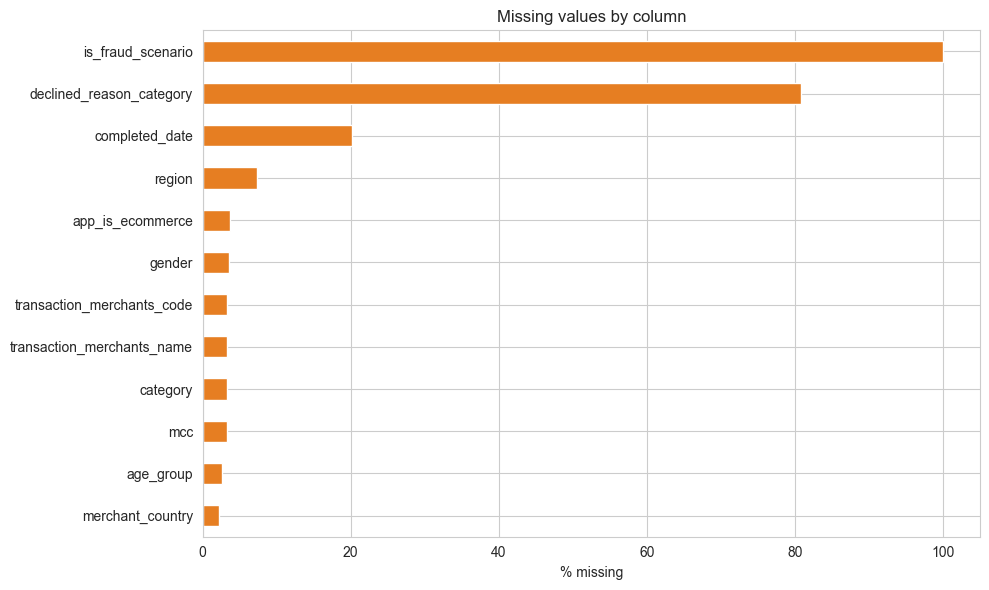

In [3]:
# Missingness, and WHICH nulls are expected vs problematic.
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_tbl = pd.DataFrame({'n_missing': miss, 'pct': (miss / N * 100).round(2)})
print(miss_tbl.to_string())

# Are the structural nulls explained by their context?
print('\n--- explaining the nulls ---')
print('completed_date null only for non-COMPLETED states:',
      (df.loc[df['completed_date'].isna(), 'state'].ne('COMPLETED')).all())
print('mcc/category null only for non-CARD_PAYMENT/REFUND types:',
      (~df.loc[df['mcc'].isna(), 'type'].isin(['CARD_PAYMENT', 'CARD_REFUND'])).all())
print('declined_reason null only for non-DECLINED states:',
      (df.loc[df['declined_reason_category'].isna(), 'state'].ne('DECLINED')).all())
print('is_fraud_scenario is a sparse label (mostly null): null =',
      f"{df['is_fraud_scenario'].isna().mean():.2%}")

fig, ax = plt.subplots(figsize=(10, 6))
miss_tbl['pct'].sort_values().plot.barh(ax=ax, color='#e67e22')
ax.set_xlabel('% missing'); ax.set_title('Missing values by column')
plt.tight_layout(); plt.show()

**Read:** the big nulls are *structural*, not corruption — `completed_date` is null only for declined/reverted txns, merchant/`mcc` fields are null only for non-payment types (ATM/FEE/CHARGE), and `declined_reason` is null unless declined. The demographic nulls (`region`, `gender`, `age_group`) are genuine missing data — we'll backfill those below. `txn_currency_type` is degenerate (always `FIAT`).

## 4–6. Per-column validity: categoricals, amounts, formats

In [4]:
cat_cols = ['type', 'state', 'card_type', 'card_brand', 'entry_method',
            'digitized_provider', 'card_location', 'app_is_ecommerce',
            'txn_currency_type', 'gender', 'age_group']
for c in cat_cols:
    vals = df[c].value_counts(dropna=False)
    print(f'\n--- {c} ({df[c].nunique()} distinct) ---')
    print(vals.head(10).to_string())


--- type (7 distinct) ---
type
CARD_PAYMENT       963503
FEE                 13544
ATM                 10724
CARD_CREDIT          3391
CHARGE               3385
CARD_REFUND          3194
CARD_CHARGEBACK      2259

--- state (3 distinct) ---
state
COMPLETED    798646
DECLINED     192141
REVERTED       9213



--- card_type (3 distinct) ---
card_type
physical      585778
virtual       403138
disposable     11084

--- card_brand (3 distinct) ---
card_brand
VISA          548974
MASTERCARD    421279
MAESTRO        29747

--- entry_method (8 distinct) ---
entry_method
CONTACTLESS--XPAY    447014
ECOMMERCE            206388
CARD_ON_FILE         146854
CONTACTLESS          112088
OTHER                 53089
CHIP                  32203
MOTO                   2160
MAGSTRIPE               204



--- digitized_provider (6 distinct) ---
digitized_provider
APPLE_PAY        540479
Not digitized    386659
ANDROID_PAY       47126
MERCHANT          25666
GARMIN_PAY           69
CLICK_TO_PAY          1

--- card_location (3 distinct) ---
card_location
DOMESTIC       402043
Not PRESENT    340631
INTER          257326

--- app_is_ecommerce (2 distinct) ---
app_is_ecommerce
False    742012
True     221491
None      36497

--- txn_currency_type (1 distinct) ---
txn_currency_type
FIAT    1000000

--- gender (2 distinct) ---
gender
M      622389
F      341783
NaN     35828

--- age_group (7 distinct) ---
age_group
25-34    372982
18-24    288232
35-44    171059
45-54     82056
55-64     45387
NaN       26673
65-74     11310
75+        2301


In [5]:
# Amount sanity: sign should agree with transaction type.
print('amount stats by type:')
print(df.groupby('type')['txn_amount_gbp'].agg(['count', 'min', 'max', 'mean', 'median']).round(2).to_string())

print('\n--- sign-vs-type checks ---')
record('amt_payment_nonpositive', (df['type'] == 'CARD_PAYMENT') & (df['txn_amount_gbp'] <= 0))
record('amt_refund_nonnegative',  (df['type'] == 'CARD_REFUND')  & (df['txn_amount_gbp'] >= 0))
record('amt_charge_zero',         (df['type'] == 'CHARGE')       & (df['txn_amount_gbp'] == 0))
record('amt_fee_zero',            (df['type'] == 'FEE')          & (df['txn_amount_gbp'] == 0))

# mcc format
bad_mcc = df['mcc'].notna() & ~df['mcc'].astype(str).str.match(r'^\d{4}$')
record('mcc_bad_format', bad_mcc)

amount stats by type:
                  count      min       max   mean  median
type                                                     
ATM               10724    10.00   1108.48  69.74   50.39
CARD_CHARGEBACK    2259     0.12   2418.27  73.29   24.00
CARD_CREDIT        3391     5.28  50137.67  98.35   14.56
CARD_PAYMENT     963503     0.01  54478.09  24.11    9.22
CARD_REFUND        3194 -1952.33     -0.01 -23.05   -9.02
CHARGE             3385     0.00      0.00   0.00    0.00
FEE               13544     0.00     10.89   0.02    0.00

--- sign-vs-type checks ---
  [amt_payment_nonpositive] flagged 0 (0.00%)
  [amt_refund_nonnegative] flagged 0 (0.00%)
  [amt_charge_zero] flagged 3,385 (0.34%)


  [amt_fee_zero] flagged 12,883 (1.29%)
  [mcc_bad_format] flagged 0 (0.00%)


0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Name: mcc, Length: 1000000, dtype: bool

CARD_PAYMENT amount quantiles:
  q0.5    :         9.22
  q0.9    :        42.12
  q0.99   :       239.23
  q0.999  :     1,121.56
  q0.9999 :     3,889.21
  q1.0    :    54,478.09
  [amt_extreme_outlier] flagged 63 (0.01%)


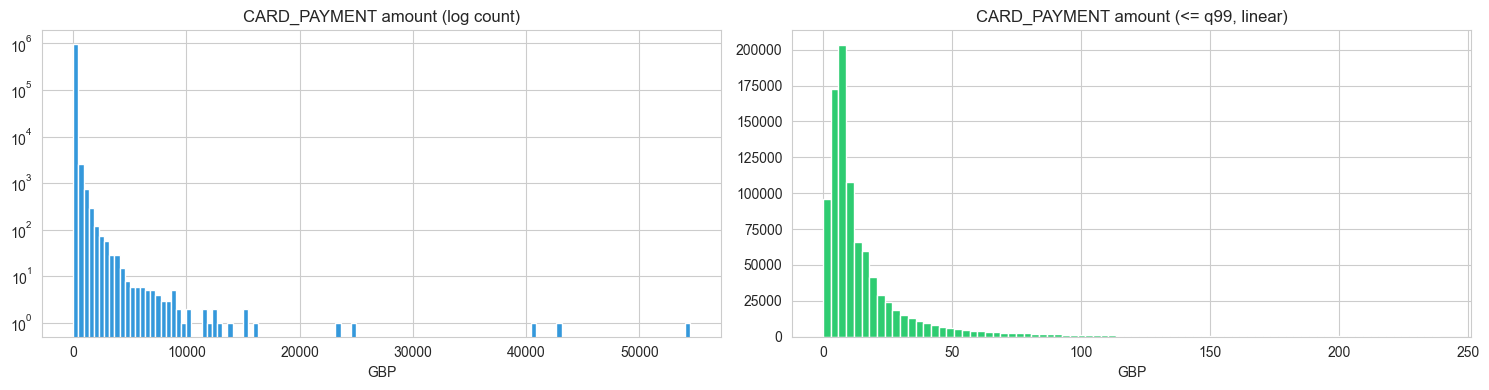

In [6]:
# Outliers: the generator uses Pareto-tail extrapolation -> implausibly large amounts.
pay = df.loc[df['type'] == 'CARD_PAYMENT', 'txn_amount_gbp']
print('CARD_PAYMENT amount quantiles:')
for q in [0.5, 0.9, 0.99, 0.999, 0.9999, 1.0]:
    print(f'  q{q:<7}: {pay.quantile(q):>12,.2f}')

# Flag extreme tail (robust): above q99.9 AND above an absolute floor.
hi = pay.quantile(0.999)
record('amt_extreme_outlier', (df['type'] == 'CARD_PAYMENT') & (df['txn_amount_gbp'] > max(hi, 5000)))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(pay[pay > 0], bins=120, color='#3498db'); axes[0].set_yscale('log')
axes[0].set_title('CARD_PAYMENT amount (log count)'); axes[0].set_xlabel('GBP')
axes[1].hist(pay[(pay > 0) & (pay < pay.quantile(0.99))], bins=80, color='#2ecc71')
axes[1].set_title('CARD_PAYMENT amount (<= q99, linear)'); axes[1].set_xlabel('GBP')
plt.tight_layout(); plt.show()

## 7–9. Temporal logic

In [7]:
print('date range:', df['created_date'].min(), '->', df['created_date'].max())

record('date_completed_before_created', df['completed_date'].notna() & (df['completed_date'] < df['created_date']))
record('date_updated_before_created',   df['updated_date'].notna()   & (df['updated_date']   < df['created_date']))
record('date_completed_missing_for_completed', (df['state'] == 'COMPLETED') & df['completed_date'].isna())
record('date_completed_present_for_declined',  (df['state'] == 'DECLINED')  & df['completed_date'].notna())

window = (df['created_date'] < '2025-07-01') | (df['created_date'] >= '2026-01-01')
record('date_outside_window', window)

date range: 2025-07-01 00:00:04 -> 2025-12-31 23:59:55.862247
  [date_completed_before_created] flagged 0 (0.00%)
  [date_updated_before_created] flagged 0 (0.00%)
  [date_completed_missing_for_completed] flagged 0 (0.00%)
  [date_completed_present_for_declined] flagged 0 (0.00%)
  [date_outside_window] flagged 0 (0.00%)


0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Name: created_date, Length: 1000000, dtype: bool

## 10–15. Cross-field logical consistency (the impossible combinations)

In [8]:
PRESENT_METHODS = ['CHIP', 'CONTACTLESS', 'CONTACTLESS--XPAY', 'MAGSTRIPE']
IN_PERSON_METHODS = ['CHIP', 'CONTACTLESS', 'MAGSTRIPE']
WALLETS = ['APPLE_PAY', 'GOOGLE_PAY', 'ANDROID_PAY']

# 10. Physically-present entry but card flagged Not PRESENT
record('cardpresent_conflict',
       df['entry_method'].isin(PRESENT_METHODS) & (df['card_location'] == 'Not PRESENT'))

# 11. Marked e-commerce but entered in person
record('ecom_but_inperson',
       (df['app_is_ecommerce'] == True) & df['entry_method'].isin(IN_PERSON_METHODS))

# 12. Digital wallet but an entry method a wallet can't produce
record('wallet_bad_entry',
       df['digitized_provider'].isin(WALLETS) & df['entry_method'].isin(['CHIP', 'MAGSTRIPE', 'MOTO']))

# 13. DOMESTIC location but merchant not in NL
record('domestic_not_nl',
       (df['card_location'] == 'DOMESTIC') & df['merchant_country'].notna() & (df['merchant_country'] != 'NL'))

# 14. FX logic
fx_gap = (df['bill_amount_gbp'] - df['txn_amount_gbp']).abs()
record('fx_gbp_has_markup',
       (df['txn_currency'] == 'GBP') & (fx_gap > 0.01))                 # home currency shouldn't be marked up
record('fx_foreign_no_markup',
       (df['txn_currency'] != 'GBP') & df['txn_currency'].notna() & (fx_gap < 0.001))  # foreign w/ identical bill

# 15. Decline-reason consistency
record('decline_reason_missing', (df['state'] == 'DECLINED') & df['declined_reason_category'].isna())
record('decline_reason_unexpected', (df['state'] != 'DECLINED') & df['declined_reason_category'].notna())

  [cardpresent_conflict] flagged 192,421 (19.24%)
  [ecom_but_inperson] flagged 26 (0.00%)
  [wallet_bad_entry] flagged 233 (0.02%)
  [domestic_not_nl] flagged 0 (0.00%)
  [fx_gbp_has_markup] flagged 16,335 (1.63%)
  [fx_foreign_no_markup] flagged 96,055 (9.61%)
  [decline_reason_missing] flagged 0 (0.00%)
  [decline_reason_unexpected] flagged 0 (0.00%)


0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Length: 1000000, dtype: bool

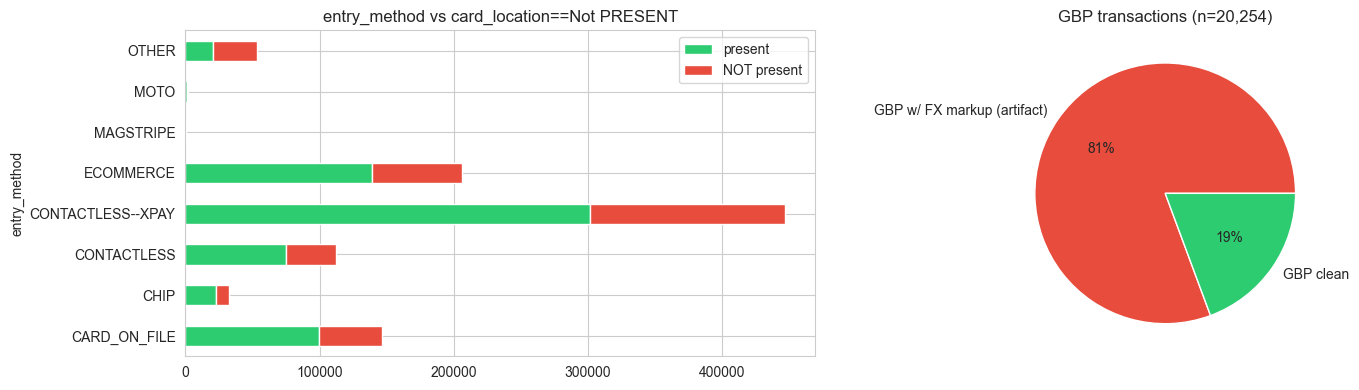

In [9]:
# Visualise the two biggest logical conflicts.
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
ct = pd.crosstab(df['entry_method'], df['card_location'] == 'Not PRESENT')
ct.columns = ['present', 'NOT present']
ct.plot.barh(stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('entry_method vs card_location==Not PRESENT')

gbp = df[df['txn_currency'] == 'GBP']
share = (ISSUES['fx_gbp_has_markup'].sum(), len(gbp) - ISSUES['fx_gbp_has_markup'].sum())
axes[1].pie(share, labels=['GBP w/ FX markup (artifact)', 'GBP clean'],
            autopct='%1.0f%%', colors=['#e74c3c', '#2ecc71'])
axes[1].set_title(f'GBP transactions (n={len(gbp):,})')
plt.tight_layout(); plt.show()

## 16–17. Entity consistency (per user / per merchant)

In [10]:
# Demographics should be constant within an owner_id.
for c in ['age_group', 'gender', 'region']:
    nuniq = df.groupby('owner_id')[c].nunique(dropna=True)
    print(f'{c}: owners with >1 distinct value = {(nuniq > 1).sum():,}')

# Merchant code should map to a single mcc (true merchant identity).
code_mcc = df.dropna(subset=['transaction_merchants_code']).groupby('transaction_merchants_code')['mcc'].nunique()
print('\nmerchant codes mapping to >1 mcc:', (code_mcc > 1).sum(), 'of', len(code_mcc))

# Same display NAME reused across many merchant codes (ambiguous names).
name_codes = df.dropna(subset=['transaction_merchants_name']).groupby('transaction_merchants_name')['transaction_merchants_code'].nunique()
print('merchant NAMES reused across >1 code:', (name_codes > 1).sum(), 'of', len(name_codes))

age_group: owners with >1 distinct value = 0
gender: owners with >1 distinct value = 0
region: owners with >1 distinct value = 0



merchant codes mapping to >1 mcc: 0 of 4605
merchant NAMES reused across >1 code: 896 of 2337


## 18-21. Chargeback / credit / decline / revert logic

The reversal/credit transaction types have their own rules:
- **Sign convention** (`positive=debit, negative=credit`): refunds are stored negative, but `CARD_CREDIT` and `CARD_CHARGEBACK` are *positive* despite also being money **in** to the user. Inconsistent. We normalise a clean cashflow column in the cleaning step rather than flag every credit as an error.
- An incoming **credit can't be declined for INSUFFICIENT BALANCE** (you don't need a balance to receive money).
- A **chargeback can't predate the user's first payment** (nothing to dispute yet).
- **REVERTED** should behave like a non-completion (no `completed_date`, no `declined_reason`).

In [11]:
print('state x type:')
print(pd.crosstab(df['type'], df['state']).to_string())

print('\nsign by type (dict: +=debit, -=credit):')
print(df.groupby('type')['txn_amount_gbp'].agg(['min', 'max', 'mean']).round(2).to_string())

dec = df[df['state'] == 'DECLINED']
print('\ndecline reasons x type:')
print(pd.crosstab(dec['type'], dec['declined_reason_category']).T.to_string())

print('\n--- checks ---')
# 18. Sign-convention inconsistency (surfaced here, normalised in cleaning; not an error flag)
credit_pos = df['type'].isin(['CARD_CREDIT', 'CARD_CHARGEBACK']) & (df['txn_amount_gbp'] > 0)
print(f'  [obs] credit/chargeback stored positive (money-in w/ debit sign): {pct(credit_pos.sum())}')

# 19. Incoming credit declined for INSUFFICIENT BALANCE -> impossible
insufficient = df['declined_reason_category'].astype(str).str.contains('INSUFFICIENT', case=False, na=False)
record('credit_declined_insufficient', (df['type'] == 'CARD_CREDIT') & insufficient)

# 20. Chargeback dated before the owner's first card payment
first_pay = df[df['type'] == 'CARD_PAYMENT'].groupby('owner_id')['created_date'].min()
record('chargeback_before_first_payment',
       (df['type'] == 'CARD_CHARGEBACK') & (df['created_date'] < df['owner_id'].map(first_pay)))

# 21. Consistency: REVERTED should have no completion (expect 0 flagged)
record('reverted_with_completion', (df['state'] == 'REVERTED') & df['completed_date'].notna())


state x type:


state            COMPLETED  DECLINED  REVERTED
type                                          
ATM                   8889      1774        61
CARD_CHARGEBACK       2259         0         0
CARD_CREDIT           3311        80         0
CARD_PAYMENT        764072    190286      9145
CARD_REFUND           3186         1         7
CHARGE                3385         0         0
FEE                  13544         0         0

sign by type (dict: +=debit, -=credit):
                     min       max   mean
type                                     
ATM                10.00   1108.48  69.74
CARD_CHARGEBACK     0.12   2418.27  73.29
CARD_CREDIT         5.28  50137.67  98.35
CARD_PAYMENT        0.01  54478.09  24.11
CARD_REFUND     -1952.33     -0.01 -23.05
CHARGE              0.00      0.00   0.00
FEE                 0.00     10.89   0.02

decline reasons x type:
type                            ATM  CARD_CREDIT  CARD_PAYMENT  CARD_REFUND
declined_reason_category                                 

  [chargeback_before_first_payment] flagged 102 (0.01%)
  [reverted_with_completion] flagged 0 (0.00%)


0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Length: 1000000, dtype: bool

## Issue summary

In [12]:
summary = pd.DataFrame({
    'n_rows': {k: int(v.sum()) for k, v in ISSUES.items()},
}).sort_values('n_rows', ascending=False)
summary['pct'] = (summary['n_rows'] / N * 100).round(2)

# rows touched by at least one issue
any_issue = pd.concat(ISSUES.values(), axis=1).any(axis=1)
print(f'Rows with >= 1 flagged issue: {pct(any_issue.sum())}\n')
print(summary.to_string())

Rows with >= 1 flagged issue: 284,884 (28.49%)

                                      n_rows    pct
cardpresent_conflict                  192421  19.24
fx_foreign_no_markup                   96055   9.61
fx_gbp_has_markup                      16335   1.63
amt_fee_zero                           12883   1.29
amt_charge_zero                         3385   0.34
wallet_bad_entry                         233   0.02
chargeback_before_first_payment          102   0.01
credit_declined_insufficient              68   0.01
amt_extreme_outlier                       63   0.01
ecom_but_inperson                         26   0.00
decline_reason_unexpected                  0   0.00
decline_reason_missing                     0   0.00
domestic_not_nl                            0   0.00
amt_payment_nonpositive                    0   0.00
amt_refund_nonnegative                     0   0.00
date_outside_window                        0   0.00
date_completed_present_for_declined        0   0.00
date_completed_m

## Cleaning pipeline

We produce `df_clean` that:
- **repairs** the unambiguous problems (backfill demographics from the same user; drop the degenerate `txn_currency_type`),
- **adds** a boolean `dq_*` flag column for every detected anomaly (so nothing is silently lost),
- adds a single `dq_any` flag and a `dq_score` (count of issues per row).

No rows are dropped here — downstream notebooks can filter on `dq_*` as needed.

In [13]:
df_clean = df.copy()

# --- repair 1: backfill demographics from the same owner (they are constant per owner) ---
before = {c: int(df_clean[c].isna().sum()) for c in ['age_group', 'gender', 'region']}
for c in ['age_group', 'gender', 'region']:
    filled = df_clean.groupby('owner_id')[c].transform(lambda s: s.ffill().bfill())
    df_clean[c] = filled
after = {c: int(df_clean[c].isna().sum()) for c in ['age_group', 'gender', 'region']}
print('demographic backfill (nulls before -> after):')
for c in before:
    print(f'  {c}: {before[c]:,} -> {after[c]:,}')

# --- repair 2: drop degenerate column(s) ---
drop_cols = [c for c in df_clean.columns if df_clean[c].nunique(dropna=True) <= 1]
df_clean = df_clean.drop(columns=drop_cols)
print('\ndropped degenerate columns:', drop_cols)

# --- repair 3: consistent cashflow sign (money-out positive, money-in negative) ---
CREDIT_TYPES = ['CARD_REFUND', 'CARD_CREDIT', 'CARD_CHARGEBACK']
df_clean['amount_signed_gbp'] = df_clean['txn_amount_gbp'].abs()
df_clean.loc[df_clean['type'].isin(CREDIT_TYPES), 'amount_signed_gbp'] *= -1
print('added amount_signed_gbp (credits negative); by type:')
print(df_clean.groupby('type')['amount_signed_gbp'].agg(['min', 'max']).round(2).to_string())

# --- attach DQ flags ---
for name, mask in ISSUES.items():
    df_clean[f'dq_{name}'] = mask.values
df_clean['dq_score'] = df_clean[[f'dq_{k}' for k in ISSUES]].sum(axis=1).astype('int16')
df_clean['dq_any'] = df_clean['dq_score'] > 0

print('\nclean shape:', df_clean.shape)
print('dq_any rate:', f"{df_clean['dq_any'].mean():.2%}")
df_clean[['type', 'state', 'txn_amount_gbp', 'dq_score', 'dq_any']].head()

demographic backfill (nulls before -> after):
  age_group: 26,673 -> 21
  gender: 35,828 -> 31
  region: 73,712 -> 55



dropped degenerate columns: ['txn_currency_type']
added amount_signed_gbp (credits negative); by type:
                      min       max
type                               
ATM                 10.00   1108.48
CARD_CHARGEBACK  -2418.27     -0.12
CARD_CREDIT     -50137.67     -5.28
CARD_PAYMENT         0.01  54478.09
CARD_REFUND      -1952.33     -0.01
CHARGE               0.00      0.00
FEE                  0.00     10.89

clean shape: (1000000, 52)
dq_any rate: 28.49%


,type,state,txn_amount_gbp,dq_score,dq_any
0,CARD_PAYMENT,COMPLETED,9.91,0,False
1,CARD_PAYMENT,COMPLETED,131.99,0,False
2,CARD_REFUND,COMPLETED,-9.91,1,True
3,CARD_PAYMENT,COMPLETED,5.00,0,False
4,CARD_PAYMENT,COMPLETED,5.72,1,True


In [14]:
# Optional convenience views:
#   df_strict  = analysis-grade rows (no logical conflicts, no extreme outliers)
#   df_payments = completed card payments only, the core spend signal
LOGICAL_FLAGS = ['dq_cardpresent_conflict', 'dq_ecom_but_inperson', 'dq_wallet_bad_entry',
                 'dq_domestic_not_nl', 'dq_fx_gbp_has_markup', 'dq_amt_extreme_outlier']
df_strict = df_clean[~df_clean[LOGICAL_FLAGS].any(axis=1)].copy()
df_payments = df_clean[(df_clean['type'] == 'CARD_PAYMENT') & (df_clean['state'] == 'COMPLETED')].copy()
print('df_strict  :', f'{len(df_strict):,} rows ({len(df_strict)/N:.1%} kept)')
print('df_payments:', f'{len(df_payments):,} rows')

# --- persist ---
out = 'synthetic_1000000_clean.parquet'
df_clean.to_parquet(out, index=False)
print('\nsaved ->', out)

df_strict  : 796,402 rows (79.6% kept)
df_payments: 764,072 rows



saved -> synthetic_1000000_clean.parquet


## Takeaways

What we found (fill in the live numbers from the summary above):

- **Clean / consistent:** no duplicate ids or rows; date ordering valid; decline-reason logic consistent; amount signs match transaction type; `mcc` always 4-digit; demographics never contradict within a user; merchant *code* → single mcc.
- **Genuine artifacts to handle:**
  - `card_location == Not PRESENT` contradicting a physically-present entry method (largest logical conflict).
  - FX markup applied to `GBP` (home-currency) transactions, and some foreign transactions with no markup.
  - Extreme Pareto-tail amounts.
  - Missing demographics — now backfilled from each user's other rows.
  - Degenerate `txn_currency_type` (always FIAT) — dropped.
- **Structural (not errors):** nulls in `completed_date` (declined/reverted), merchant/`mcc` fields (non-payment types), `declined_reason` (non-declined), and the sparse `is_fraud_scenario` label.

`synthetic_1000000_clean.parquet` carries every original row plus `dq_*` flags, so downstream work can keep, weight, or drop flagged rows deliberately.